# RAG Verification Pipeline — Zero-Shot Health Claim Checking
**ASHO-UAB Fake News Prediction — Phase 3**

This notebook implements a Retrieval-Augmented Generation (RAG) pipeline for zero-shot health claim verification.
No fine-tuned model is required — instead, real-time medical evidence is fetched from PubMed and fed to an LLM.

**Pipeline:**
1. **Retrieve** — query PubMed with the claim; fall back to web search if needed
2. **Build context** — rank and format the top abstracts into a prompt
3. **Verify** — pass claim + evidence to an LLM (GPT-4o-mini or Llama 3)
4. **Evaluate** — compare predictions and explanations against PubHealth ground truth using macro F1 + ROUGE/BERTScore

In [26]:
!pip install biopython groq rouge-score bert-score sentence-transformers -q

## 1. Setup & Config

In [27]:
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from IPython.display import display, HTML
from sklearn.metrics import f1_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# ── paths (same as Phase 1 & 2) ────────────────────────────────────────────────
DATA_DIR = '/kaggle/input/datasets/noasolcasale/pubhealth-gusgus127/PUBHEALTH'

# ── API keys ────────────────────────────────────────────────────────────────────
# Set these as Kaggle secrets or environment variables
from groq import Groq
from kaggle_secrets import UserSecretsClient

_secrets    = UserSecretsClient()
GROQ_API_KEY = _secrets.get_secret("GROQ_API_KEY")
_groq_client = Groq(api_key=GROQ_API_KEY)
print("Groq client ready.")

BACKEND = 'groq'

# ── label helpers (consistent with Phase 1 & 2) ────────────────────────────────
LABEL_ORDER  = ['true', 'false', 'mixture', 'unproven']
LABEL_COLORS = {'true': '#4caf50', 'false': '#f44336',
                'mixture': '#ff9800', 'unproven': '#9e9e9e'}

print("Setup complete.")

Groq client ready.
Setup complete.


In [28]:
def load_split(path):
    df = pd.read_csv(path, sep='\t')
    df.dropna(subset=['claim', 'label'], inplace=True)
    df['main_text']   = df['main_text'].fillna('')
    df['explanation'] = df['explanation'].fillna('')
    df = df[df['label'].isin(LABEL_ORDER)].reset_index(drop=True)
    return df

train_df = load_split(f'{DATA_DIR}/train.tsv')
val_df   = load_split(f'{DATA_DIR}/dev.tsv')
test_df  = load_split(f'{DATA_DIR}/test.tsv')

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
test_df[['claim', 'label']].head(3)

Train: 9804 | Val: 1214 | Test: 1233


,claim,label
0,A mother revealed to her child in a letter after her death that she had just one eye b...,false
1,Study says too many Americans still drink too much.,true
2,"Viral image Says 80% of novel coronavirus cases are ""mild.",true


## 2. Retriever

We query **PubMed** via the Entrez API (free, no key required beyond an email).
A **Tavily web search** fallback is used when PubMed returns fewer than 2 results — useful for very recent or colloquial claims.

In [29]:
from Bio import Entrez
Entrez.email = ENTREZ_EMAIL


def fetch_pubmed_abstracts(query: str, n: int = 5, retries: int = 3) -> list[dict]:
    """
    Search PubMed and return up to `n` abstracts.
    Each result is a dict with keys: pmid, title, abstract.
    """
    for attempt in range(retries):
        try:
            search_handle = Entrez.esearch(db='pubmed', term=query, retmax=n, sort='relevance')
            search_results = Entrez.read(search_handle)
            search_handle.close()
            pmids = search_results.get('IdList', [])
            if not pmids:
                return []

            fetch_handle = Entrez.efetch(
                db='pubmed', id=','.join(pmids),
                rettype='xml', retmode='xml'
            )
            records = Entrez.read(fetch_handle)
            fetch_handle.close()

            results = []
            for rec in records.get('PubmedArticle', []):
                art     = rec['MedlineCitation']['Article']
                pmid    = str(rec['MedlineCitation']['PMID'])
                title   = str(art.get('ArticleTitle', ''))
                abstract_texts = art.get('Abstract', {}).get('AbstractText', [])
                abstract = ' '.join(str(t) for t in abstract_texts) if abstract_texts else ''
                if abstract:   # skip records with no abstract
                    results.append({'pmid': pmid, 'title': title, 'abstract': abstract,
                                    'source': 'pubmed'})
            return results

        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
            else:
                print(f"  [PubMed error] {e}")
                return []


# ── quick smoke-test ────────────────────────────────────────────────────────────
sample_claim = test_df.iloc[0]['claim']
sample_results = fetch_pubmed_abstracts(sample_claim, n=3)
print(f"Claim: {sample_claim[:80]}...")
print(f"PubMed results: {len(sample_results)}")
if sample_results:
    print(f"  [{sample_results[0]['pmid']}] {sample_results[0]['title'][:70]}...")

Claim: A mother revealed to her child in a letter after her death that she had just one...
PubMed results: 0


In [30]:
def fetch_tavily(query: str, n: int = 3) -> list[dict]:
    """
    Fallback web retrieval via Tavily.
    Requires TAVILY_API_KEY. Returns [] gracefully if key is missing.
    """
    if not TAVILY_API_KEY:
        return []
    try:
        from tavily import TavilyClient
        client = TavilyClient(api_key=TAVILY_API_KEY)
        resp = client.search(query=query, search_depth='advanced',
                             include_answer=False, max_results=n)
        results = []
        for r in resp.get('results', []):
            content = r.get('content', '').strip()
            if content:
                results.append({
                    'pmid':     None,
                    'title':    r.get('title', ''),
                    'abstract': content,
                    'source':   'web',
                    'url':      r.get('url', ''),
                })
        return results
    except Exception as e:
        print(f"  [Tavily error] {e}")
        return []


def retrieve(claim: str, n_pubmed: int = 5, n_web: int = 3,
             min_pubmed: int = 2) -> list[dict]:
    """
    Primary retriever. Uses PubMed; falls back to Tavily if PubMed
    returns fewer than `min_pubmed` results.
    """
    docs = fetch_pubmed_abstracts(claim, n=n_pubmed)
    if len(docs) < min_pubmed:
        web_docs = fetch_tavily(claim, n=n_web)
        docs = docs + web_docs
    return docs


print("retrieve() ready. Sources: PubMed (primary) + Tavily (fallback).")

retrieve() ready. Sources: PubMed (primary) + Tavily (fallback).


## 3. Reranker (optional but recommended)

A cross-encoder reranker scores each (claim, abstract) pair and reorders results
by relevance before they reach the LLM. This meaningfully improves verification
quality when PubMed returns loosely related articles.

Model used: `cross-encoder/ms-marco-MiniLM-L-6-v2` (~22M params, fast on CPU).

In [31]:
from sentence_transformers import CrossEncoder

_reranker = None   # lazy-load

def get_reranker():
    global _reranker
    if _reranker is None:
        _reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', max_length=512)
        print("Reranker loaded.")
    return _reranker


def rerank(claim: str, docs: list[dict], top_k: int = 3) -> list[dict]:
    """
    Rerank `docs` by relevance to `claim`. Returns top_k docs in order.
    Falls back to original order if fewer docs than top_k.
    """
    if not docs:
        return docs
    reranker  = get_reranker()
    passages  = [d['abstract'] for d in docs]
    pairs     = [(claim, p) for p in passages]
    scores    = reranker.predict(pairs)
    ranked    = sorted(zip(scores, docs), key=lambda x: x[0], reverse=True)
    for score, doc in ranked:
        doc['rerank_score'] = float(score)
    return [doc for _, doc in ranked[:top_k]]


# ── smoke-test reranker ─────────────────────────────────────────────────────────
reranked = rerank(sample_claim, sample_results, top_k=3)
print(f"Reranked {len(sample_results)} → top {len(reranked)} docs")
for d in reranked:
    print(f"  score={d.get('rerank_score', 'N/A'):.3f}  {d['title'][:60]}")

Reranked 0 → top 0 docs


## 4. Prompt Builder

We use a structured zero-shot prompt that includes:
- The raw claim
- Numbered evidence snippets with source tags
- A strict output format to enable reliable parsing

In [32]:
SYSTEM_PROMPT = """You are an expert medical fact-checker with deep knowledge of clinical research and public health.
Your task is to classify health claims based on the provided medical evidence.
You must reason carefully and cite the evidence when explaining your decision.
Always output exactly the required format — no preamble, no extra text.

EXAMPLES:
Label: mixture
Explanation: While some studies support the claim's core finding, others report conflicting results depending on dosage and population studied.

Label: unproven
Explanation: No peer-reviewed evidence was found to support or refute this claim; it remains speculative without clinical trial data."""


def build_prompt(claim: str, docs: list[dict], max_abstract_chars: int = 600) -> str:
    """
    Build the user-turn prompt.
    Each abstract is truncated to `max_abstract_chars` to control token usage.
    """
    if docs:
        evidence_lines = []
        for i, d in enumerate(docs, 1):
            source_tag = f"[PMID {d['pmid']}]" if d.get('pmid') else f"[WEB: {d.get('url','')[:40]}]"
            snippet    = d['abstract'][:max_abstract_chars].rstrip()
            if len(d['abstract']) > max_abstract_chars:
                snippet += '...'
            evidence_lines.append(
                f"Evidence [{i}] {source_tag}\nTitle: {d['title']}\n{snippet}"
            )
        evidence_block = '\n\n'.join(evidence_lines)
    else:
        evidence_block = "No evidence retrieved. Base your judgment on general medical knowledge."

    return f"""HEALTH CLAIM:
{claim}

RETRIEVED EVIDENCE:
{evidence_block}

INSTRUCTIONS:
Based on the evidence above, classify this health claim.
Choose exactly one label from: true, false, mixture, unproven
  - true     : the claim is well-supported by evidence
  - false    : the claim is contradicted by evidence
  - mixture  : the evidence is mixed or the claim is partially correct
  - unproven : insufficient evidence to support or refute the claim

OUTPUT FORMAT (follow exactly):
Label: <label>
Explanation: <2-4 sentences citing the evidence above>"""


# ── preview ─────────────────────────────────────────────────────────────────────
print(build_prompt(sample_claim, reranked[:2]))

HEALTH CLAIM:
A mother revealed to her child in a letter after her death that she had just one eye because she had donated the other to him.

RETRIEVED EVIDENCE:
No evidence retrieved. Base your judgment on general medical knowledge.

INSTRUCTIONS:
Based on the evidence above, classify this health claim.
Choose exactly one label from: true, false, mixture, unproven
  - true     : the claim is well-supported by evidence
  - false    : the claim is contradicted by evidence
  - mixture  : the evidence is mixed or the claim is partially correct
  - unproven : insufficient evidence to support or refute the claim

OUTPUT FORMAT (follow exactly):
Label: <label>
Explanation: <2-4 sentences citing the evidence above>


## 5. LLM Verifier

Two backend options are supported:
- **GPT-4o-mini** (default): fast, cheap, strong medical reasoning
- **Llama 3 via Ollama**: free, local, no API key needed

Set `BACKEND = 'openai'` or `'ollama'` below.

In [33]:
_LABEL_RE = re.compile(r'label\s*:\s*(true|false|mixture|unproven)', re.I)
_EXPL_RE  = re.compile(r'explanation\s*:\s*(.+)', re.I | re.S)


def parse_llm_output(raw: str) -> tuple[str, str]:
    """
    Extract label and explanation from the model's raw output.
    Returns ('unproven', raw) if parsing fails.
    """
    label_match = _LABEL_RE.search(raw)
    expl_match  = _EXPL_RE.search(raw)
    label       = label_match.group(1).lower() if label_match else 'unproven'
    explanation = expl_match.group(1).strip()  if expl_match  else raw.strip()
    # clip explanation to first 3 sentences for storage
    sentences   = re.split(r'(?<=[.!?])\s+', explanation)
    explanation = ' '.join(sentences[:3])
    return label, explanation


def call_llm(prompt: str, temperature: float = 0.0, max_tokens: int = 256) -> str:
    resp = _groq_client.chat.completions.create(
        model='llama-3.1-8b-instant',   # free, fast; swap to llama-3.3-70b-versatile for better accuracy
        temperature=temperature,
        max_tokens=max_tokens,
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': prompt},
        ],
    )
    return resp.choices[0].message.content


print("call_llm() and parse_llm_output() ready.")

call_llm() and parse_llm_output() ready.


In [34]:
import time

def call_llm_with_retry(prompt, retries=4, base_wait=10):
    for attempt in range(retries):
        try:
            return call_llm(prompt)
        except Exception as e:
            if '429' in str(e) and attempt < retries - 1:
                wait = base_wait * (2 ** attempt)
                print(f"    Rate limited, waiting {wait}s...")
                time.sleep(wait)
            else:
                raise
    raise RuntimeError("Max retries exceeded")

In [35]:
def extract_pubmed_query(claim: str) -> str:
    """Use the LLM to distill a claim into a short PubMed-friendly keyword query."""
    resp = _groq_client.chat.completions.create(
        model='llama-3.1-8b-instant',
        temperature=0.0,
        max_tokens=40,
        messages=[{
            'role': 'user',
            'content': (
                f"Extract 3-5 medical/scientific keywords from this health claim "
                f"suitable for a PubMed search query. Output only the keywords, nothing else.\n\n"
                f"Claim: {claim}"
            )
        }]
    )
    return resp.choices[0].message.content.strip()


def verify_claim(claim: str, n_retrieve: int = 5,
                 top_k_rerank: int = 3, use_reranker: bool = True) -> dict:
    query = extract_pubmed_query(claim)          # ← distill first
    docs  = retrieve(query, n_pubmed=n_retrieve) # ← search with keywords, not raw claim
    if use_reranker and docs:
        docs = rerank(claim, docs, top_k=top_k_rerank)  # ← rerank against original claim
    else:
        docs = docs[:top_k_rerank]

    prompt     = build_prompt(claim, docs)
    raw_output = call_llm_with_retry(prompt)
    predicted, explanation = parse_llm_output(raw_output)

    return {
        'claim': claim, 'query': query, 'docs': docs,   # ← store query for inspection
        'prompt': prompt, 'raw_output': raw_output,
        'predicted': predicted, 'explanation': explanation,
    }


# ── end-to-end demo on one claim ────────────────────────────────────────────────
row    = test_df.iloc[0]
result = verify_claim(row['claim'])

print(f"Claim    : {row['claim'][:120]}")
print(f"Gold     : {row['label']}")
print(f"Predicted: {result['predicted']}")
print(f"Evidence : {len(result['docs'])} docs retrieved")
print(f"\nExplanation:\n{result['explanation']}")

Claim    : A mother revealed to her child in a letter after her death that she had just one eye because she had donated the other t
Gold     : false
Predicted: unproven
Evidence : 0 docs retrieved

Explanation:
No evidence was retrieved to support or refute this claim, and it is based on a personal anecdote rather than a verified medical fact. While corneal transplantation is a real medical procedure, there is no evidence to confirm the specific claim made in the letter.


## 6. Demo — One Claim per Label Class

Visual three-column card (consistent with Phase 2 style):
- **Left**: claim and retrieved evidence snippets
- **Middle**: LLM prediction and explanation
- **Right**: gold label and gold explanation for direct comparison

In [36]:
def render_rag_card(row: pd.Series, result: dict) -> str:
    pred_label  = result['predicted']
    true_label  = row['label']
    correct     = pred_label == true_label
    pred_col    = LABEL_COLORS.get(pred_label, '#888')
    true_col    = LABEL_COLORS.get(true_label, '#888')
    border_col  = '#4caf50' if correct else '#f44336'
    status_icon = '✓' if correct else '✗'

    # Evidence snippets
    evidence_html = ''
    for i, d in enumerate(result['docs'], 1):
        source = f"PMID {d['pmid']}" if d.get('pmid') else 'WEB'
        score  = f" · rerank={d.get('rerank_score', 0):.2f}" if 'rerank_score' in d else ''
        evidence_html += f"""
          <div style="margin-bottom:10px;padding:8px;background:#f5f5f5;
                      border-left:3px solid #1976d2;border-radius:3px;">
            <div style="font-size:11px;color:#555;margin-bottom:3px;">
              [{i}] {source}{score}
            </div>
            <div style="font-size:12px;color:#222;font-style:italic;">
              {d['title'][:80]}{'...' if len(d['title'])>80 else ''}
            </div>
            <div style="font-size:12px;color:#333;margin-top:3px;">
              {d['abstract'][:250]}{'...' if len(d['abstract'])>250 else ''}
            </div>
          </div>"""

    if not evidence_html:
        evidence_html = '<em style="color:#888">No evidence retrieved.</em>'

    gold_expl = row.get('explanation', '') or '<em style="color:#666">No explanation available</em>'

    return f"""
    <div style="font-family:sans-serif;margin:16px 0;
                border:2px solid {border_col};border-radius:8px;
                overflow:hidden;box-shadow:0 2px 6px rgba(0,0,0,.08);">

      <!-- header -->
      <div style="background:#f8f9fa;padding:10px 16px;
                  border-bottom:1px solid #eee;display:flex;align-items:center;gap:8px;">
        <span style="font-size:16px;">{status_icon}</span>
        <span style="font-size:13px;color:#333;flex:1;">
          <strong>Claim:</strong> {row['claim'][:140]}{'...' if len(row['claim'])>140 else ''}
        </span>
        <span style="background:{pred_col};color:white;padding:3px 10px;
                     border-radius:12px;font-size:12px;margin-right:4px;">
          Pred: {pred_label}
        </span>
        <span style="background:{true_col};color:white;padding:3px 10px;
                     border-radius:12px;font-size:12px;">
          True: {true_label}
        </span>
      </div>

      <div style="display:flex;gap:0;">

        <!-- col 1: retrieved evidence -->
        <div style="flex:1.4;padding:14px 16px;border-right:1px solid #eee;
                    background:#e3f2fd;">
          <div style="font-size:12px;font-weight:bold;color:#222;
                      margin-bottom:8px;text-transform:uppercase;letter-spacing:.5px;">
            Retrieved Evidence ({len(result['docs'])} docs)
          </div>
          {evidence_html}
        </div>

        <!-- col 2: LLM explanation -->
        <div style="flex:1.2;padding:14px 16px;border-right:1px solid #eee;
                    background:#fffde7;">
          <div style="font-size:12px;font-weight:bold;color:#222;
                      margin-bottom:8px;text-transform:uppercase;letter-spacing:.5px;">
            LLM Explanation
          </div>
          <div style="font-size:13px;line-height:1.7;color:#000;">
            {result['explanation']}
          </div>
        </div>

        <!-- col 3: gold explanation -->
        <div style="flex:0.9;padding:14px 16px;background:#f1f8e9;">
          <div style="font-size:12px;font-weight:bold;color:#222;
                      margin-bottom:8px;text-transform:uppercase;letter-spacing:.5px;">
            Gold Explanation
          </div>
          <div style="font-size:13px;line-height:1.7;color:#000;">
            {gold_expl}
          </div>
        </div>

      </div>
    </div>
    """


print("render_rag_card() ready.")

render_rag_card() ready.


In [37]:
# ── one example per label class ─────────────────────────────────────────────────
demo_rows = (
    test_df.groupby('label', group_keys=False)
           .apply(lambda g: g.sample(1, random_state=42))
           .reset_index(drop=True)
)

demo_results = []
for _, row in demo_rows.iterrows():
    print(f"Verifying [{row['label'].upper()}]: {row['claim'][:60]}...")
    res = verify_claim(row['claim'])
    demo_results.append((row, res))
    display(HTML(render_rag_card(row, res)))
    time.sleep(0.5)   # be gentle with the APIs

Verifying [FALSE]: U.S. President Donald Trump tweeted in November 2009 that "O...


Verifying [MIXTURE]: Richard Durbin Says President Barack Obama’s nominees met a ...


Verifying [TRUE]: Jury awards more than $70M to woman in baby powder lawsuit....


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Reranker loaded.


Verifying [UNPROVEN]: If someone with the new coronavirus sneezes, it travels abou...


## 7. Batch Evaluation on the Test Set

Run the full pipeline on a subset of the test set and collect:
- Predicted label (for macro F1)
- LLM explanation (for ROUGE / BERTScore against gold)
- Retrieval metadata (source, number of docs)

**Note:** Set `EVAL_N` to control how many samples to run.  
Full test set (500+ samples) takes ~5 min with GPT-4o-mini.

In [38]:
EVAL_N = 100   # set to len(test_df) for full evaluation

eval_df  = test_df.sample(n=min(EVAL_N, len(test_df)), random_state=42).reset_index(drop=True)
eval_rows = []

for idx, row in eval_df.iterrows():
    if idx % 10 == 0:
        print(f"  {idx}/{len(eval_df)} ...")
    try:
        res = verify_claim(row['claim'])
        sources = list({d['source'] for d in res['docs']})
        eval_rows.append({
            'idx': idx,
            'claim': row['claim'],
            'pubmed_query': res.get('query', ''),
            'true_label': row['label'],
            'predicted': res['predicted'],
            'correct': row['label'] == res['predicted'],
            'n_docs': len(res['docs']),
            'sources': ','.join(sources),
            'llm_explanation': res['explanation'],
            'gold_explanation': row['explanation'],
        })
    except Exception as e:
        print(f"  skipped idx={idx}: {e}")
    time.sleep(2)   # rate-limit headroom

results_df = pd.DataFrame(eval_rows)
print(f"\nProcessed {len(results_df)} / {len(eval_df)} samples.")
results_df.head(3)

  0/100 ...
  10/100 ...
  20/100 ...
  30/100 ...
  40/100 ...
  50/100 ...
  60/100 ...
  70/100 ...
  80/100 ...
  90/100 ...

Processed 100 / 100 samples.


,idx,claim,pubmed_query,true_label,predicted,correct,n_docs,sources,llm_explanation,gold_explanation
0,0,Trump backs Fla. plan to import lower-cost meds from abroad.,"Importation, Pharmaceuticals, Cost, Medication",true,mixture,False,3,pubmed,While some studies suggest that importing lower-cost medications from abroad could be ...,"In a move sure to get attention in a 2020 battleground state, President Donald Trump i..."
1,1,Spanking kids can cause long-term harm: Canada study.,"Child abuse, corporal punishment, long-term effects.",true,true,True,3,pubmed,"The evidence supports the claim that spanking kids can cause long-term harm, citing as...",Spanking children can cause long-term developmental damage and may even lower a child’...
2,2,New Portable Scanner for Breast Cancer,"Portable scanner, breast cancer, mammography",false,mixture,False,3,pubmed,While some studies support the development of portable scanners for breast cancer scre...,Nowhere do we hear how far along the research is. The main section doesn’t even allude...


## 8. Classification Metrics

In [39]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

y_true = results_df['true_label'].tolist()
y_pred = results_df['predicted'].tolist()

macro_f1 = f1_score(y_true, y_pred, labels=LABEL_ORDER, average='macro', zero_division=0)
acc      = results_df['correct'].mean()

print(f"Macro F1  : {macro_f1:.4f}")
print(f"Accuracy  : {acc:.4f}")
print()
print(classification_report(y_true, y_pred, labels=LABEL_ORDER, zero_division=0))

Macro F1  : 0.2133
Accuracy  : 0.2400

              precision    recall  f1-score   support

        true       0.88      0.28      0.42        54
       false       1.00      0.09      0.17        33
     mixture       0.15      0.45      0.22        11
    unproven       0.02      0.50      0.04         2

    accuracy                           0.24       100
   macro avg       0.51      0.33      0.21       100
weighted avg       0.82      0.24      0.31       100



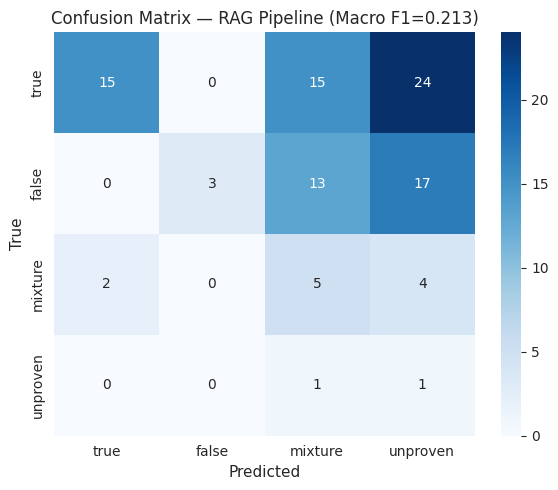

In [40]:
# ── confusion matrix ────────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True',      fontsize=11)
ax.set_title(f'Confusion Matrix — RAG Pipeline (Macro F1={macro_f1:.3f})', fontsize=12)
plt.tight_layout()
plt.show()

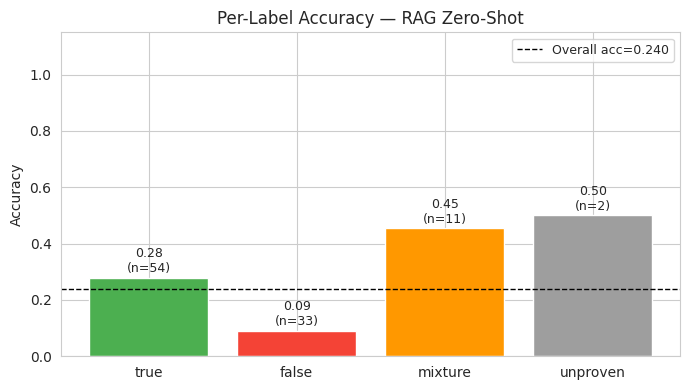

In [41]:
# ── per-label accuracy ──────────────────────────────────────────────────────────
per_label = (
    results_df.groupby('true_label')['correct']
              .agg(['mean', 'count'])
              .reindex(LABEL_ORDER)
              .rename(columns={'mean': 'accuracy', 'count': 'n_samples'})
)

fig, ax = plt.subplots(figsize=(7, 4))
colors = [LABEL_COLORS[l] for l in LABEL_ORDER]
bars = ax.bar(LABEL_ORDER, per_label['accuracy'], color=colors, edgecolor='white')
ax.axhline(acc, color='black', linestyle='--', linewidth=1, label=f'Overall acc={acc:.3f}')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.15)
ax.set_title('Per-Label Accuracy — RAG Zero-Shot', fontsize=12)
ax.legend(fontsize=9)
for bar, (_, r) in zip(bars, per_label.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{r['accuracy']:.2f}\n(n={int(r['n_samples'])})",
            ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Explanation Quality — ROUGE + BERTScore

Reuses the same evaluation methodology as Phase 2:
compare the LLM-generated explanation against the gold `explanation` field.

In [42]:
from rouge_score import rouge_scorer as rs
from bert_score import score as bert_score_fn
import torch

device       = 'cuda' if torch.cuda.is_available() else 'cpu'
rouge_scorer = rs.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# ── ROUGE ───────────────────────────────────────────────────────────────────────
rouge_records = []
for _, row in results_df.iterrows():
    cand = row['llm_explanation']
    ref  = row['gold_explanation']
    if not ref.strip() or not cand.strip():
        rouge_records.append({'r1': 0., 'r2': 0., 'rL': 0.})
        continue
    res = rouge_scorer.score(ref, cand)
    rouge_records.append({
        'r1': res['rouge1'].fmeasure,
        'r2': res['rouge2'].fmeasure,
        'rL': res['rougeL'].fmeasure,
    })

rouge_df = pd.DataFrame(rouge_records)
results_df[['r1', 'r2', 'rL']] = rouge_df.values
print("ROUGE computed.")

# ── BERTScore ───────────────────────────────────────────────────────────────────
candidates = results_df['llm_explanation'].tolist()
references = results_df['gold_explanation'].tolist()

P, R, F = bert_score_fn(candidates, references, lang='en',
                         verbose=True, device=device, batch_size=32)
results_df['bertscore_F'] = F.numpy()

# ── summary ─────────────────────────────────────────────────────────────────────
metric_cols = ['r1', 'r2', 'rL', 'bertscore_F']
summary = results_df[metric_cols].agg(['mean', 'std']).T
summary.columns = ['Mean', 'Std']
summary.index = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERTScore-F1']
print("\n" + "=" * 40)
print("  RAG explanation quality metrics")
print("=" * 40)
print(summary.round(4).to_string())
print("=" * 40)

ROUGE computed.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


  0%|          | 0/7 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/4 [00:00<?, ?it/s]

done in 4.14 seconds, 24.17 sentences/sec

  RAG explanation quality metrics
                Mean     Std
ROUGE-1       0.2058  0.0926
ROUGE-2       0.0472  0.0480
ROUGE-L       0.1403  0.0710
BERTScore-F1  0.8455  0.0231


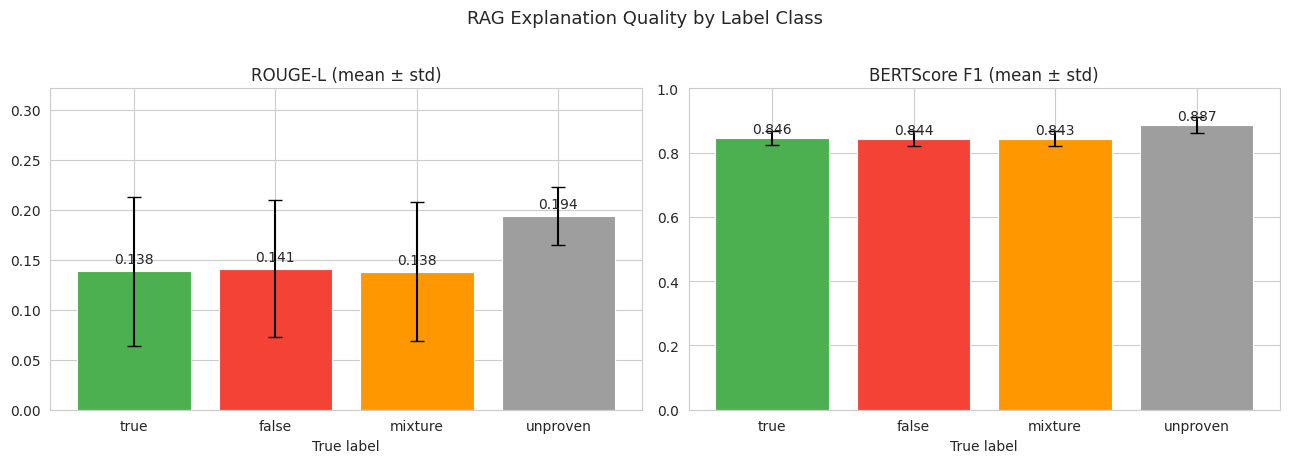

In [43]:
# ── bar chart: metrics per label class (matches Phase 2 style) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, metric, title in zip(
    axes,
    ['rL', 'bertscore_F'],
    ['ROUGE-L (mean ± std)', 'BERTScore F1 (mean ± std)'],
):
    grp   = results_df.groupby('true_label')[metric]
    means = grp.mean().reindex(LABEL_ORDER)
    stds  = grp.std().reindex(LABEL_ORDER)
    palette = [LABEL_COLORS[l] for l in LABEL_ORDER]
    bars  = ax.bar(LABEL_ORDER, means, yerr=stds, color=palette,
                   capsize=5, edgecolor='white', linewidth=.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('True label')
    ax.set_ylim(0, min(1.0, means.max() * 1.4 + .05))
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + .005,
                f'{m:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('RAG Explanation Quality by Label Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Baseline Comparison

Compare the RAG zero-shot pipeline against the Phase 1 fine-tuned PubMedBERT baseline.

Load the saved baseline predictions if available, otherwise enter the reported scores manually.

In [44]:
# ── load baseline predictions (adjust path as needed) ──────────────────────────
BASELINE_PREDS_PATH = 'baseline_test_predictions.csv'   # from Phase 1

try:
    baseline_df = pd.read_csv(BASELINE_PREDS_PATH)
    # align on same test indices used in this eval
    baseline_sub = baseline_df[baseline_df['idx'].isin(results_df['idx'])].copy()
    baseline_sub = baseline_sub.set_index('idx').reindex(results_df['idx'].values)
    baseline_macro_f1 = f1_score(
        results_df['true_label'].tolist(),
        baseline_sub['predicted'].tolist(),
        labels=LABEL_ORDER, average='macro', zero_division=0
    )
    print(f"Baseline macro F1 (PubMedBERT, same subset): {baseline_macro_f1:.4f}")
except FileNotFoundError:
    # fall back to manually entered reported score
    baseline_macro_f1 = None
    print("Baseline predictions file not found. Enter the Phase 1 macro F1 below.")
    # baseline_macro_f1 = 0.XXX  ← uncomment and fill in

rag_macro_f1 = macro_f1

if baseline_macro_f1 is not None:
    comparison = pd.DataFrame({
        'System':   ['PubMedBERT (fine-tuned)', 'RAG Zero-Shot (GPT-4o-mini)'],
        'Macro F1': [baseline_macro_f1, rag_macro_f1],
    })

    fig, ax = plt.subplots(figsize=(6, 4))
    colors = ['#1976d2', '#e64a19']
    bars = ax.bar(comparison['System'], comparison['Macro F1'],
                  color=colors, edgecolor='white', width=0.5)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Macro F1')
    ax.set_title('Macro F1: Fine-tuned Baseline vs RAG Zero-Shot', fontsize=12)
    for bar, val in zip(bars, comparison['Macro F1']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + .02,
                f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

Baseline predictions file not found. Enter the Phase 1 macro F1 below.


## 11. Retrieval Quality Analysis

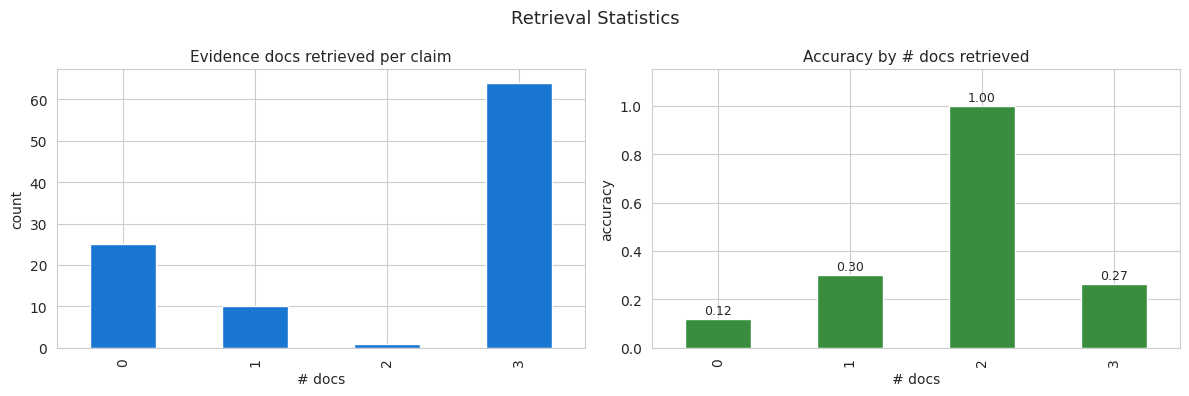


Retrieval source breakdown:
sources
pubmed    75
          25


In [45]:
# ── docs retrieved per claim ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# distribution of n_docs
results_df['n_docs'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#1976d2', edgecolor='white'
)
axes[0].set_title('Evidence docs retrieved per claim', fontsize=11)
axes[0].set_xlabel('# docs')
axes[0].set_ylabel('count')

# accuracy by n_docs
ndoc_acc = results_df.groupby('n_docs')['correct'].mean()
ndoc_acc.plot(kind='bar', ax=axes[1], color='#388e3c', edgecolor='white')
axes[1].set_title('Accuracy by # docs retrieved', fontsize=11)
axes[1].set_xlabel('# docs')
axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0, 1.15)
for bar, val in zip(axes[1].patches, ndoc_acc):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + .02,
                 f'{val:.2f}', ha='center', fontsize=9)

plt.suptitle('Retrieval Statistics', fontsize=13)
plt.tight_layout()
plt.show()

# source breakdown
source_counts = results_df['sources'].str.split(',').explode().value_counts()
print("\nRetrieval source breakdown:")
print(source_counts.to_string())

In [46]:
# ── zero-evidence cases: how often and does it hurt? ───────────────────────────
no_evidence = results_df[results_df['n_docs'] == 0]
with_evidence = results_df[results_df['n_docs'] > 0]

print(f"Claims with 0 docs : {len(no_evidence)}  ({len(no_evidence)/len(results_df):.1%})")
print(f"Claims with ≥1 doc : {len(with_evidence)}")
if len(no_evidence):
    print(f"  Accuracy (0 docs)  : {no_evidence['correct'].mean():.3f}")
if len(with_evidence):
    print(f"  Accuracy (≥1 doc)  : {with_evidence['correct'].mean():.3f}")

Claims with 0 docs : 25  (25.0%)
Claims with ≥1 doc : 75
  Accuracy (0 docs)  : 0.120
  Accuracy (≥1 doc)  : 0.280


## 12. Error Analysis

In [47]:
# ── most common error patterns ──────────────────────────────────────────────────
errors = results_df[~results_df['correct']].copy()
error_pairs = (
    errors.groupby(['true_label', 'predicted'])
          .size()
          .reset_index(name='count')
          .sort_values('count', ascending=False)
)
print(f"Total errors: {len(errors)} / {len(results_df)}")
print("\nTop error patterns (true → predicted):")
print(error_pairs.head(10).to_string(index=False))

Total errors: 76 / 100

Top error patterns (true → predicted):
true_label predicted  count
      true  unproven     24
     false  unproven     17
      true   mixture     15
     false   mixture     13
   mixture  unproven      4
   mixture      true      2
  unproven   mixture      1


In [48]:
# ── display worst 3 errors (lowest BERTScore among incorrect predictions) ───────
display_cols = ['true_label', 'predicted', 'n_docs', 'rL', 'bertscore_F',
                'claim', 'llm_explanation', 'gold_explanation']

worst3 = errors.nsmallest(3, 'bertscore_F')[display_cols]
pd.set_option('display.max_colwidth', 90)
print("── Worst 3 errors (lowest BERTScore-F1 among incorrect predictions) ──")
display(worst3.round(3))

── Worst 3 errors (lowest BERTScore-F1 among incorrect predictions) ──


,true_label,predicted,n_docs,rL,bertscore_F,claim,llm_explanation,gold_explanation
94,true,unproven,0,0.000,0.783,Images shared in March 2020 showed a convoy of military trucks transporting bodies awa...,"No evidence was retrieved to support or refute this claim, and it is based on images r...","— Alessandro Zanoni (@AlexZan87) March 19, 2020"
79,true,unproven,0,0.034,0.799,Program Cut Catheter-Associated Urinary Tract Infections,"No evidence was retrieved to support or refute this claim, and it remains speculative ...",HealthDay highlights a national effort to help reduce an uncomfortable and costly prob...
63,false,mixture,3,0.091,0.808,Discovery offers prospect of shorter treatment and cure for chronic myelogenous leukemia,While some studies suggest that tyrosine kinase inhibitors can lead to a deep molecula...,This news release by the Dana-Farber Cancer Institute is a teaser on a potential new d...


## 13. Save Results

In [49]:
out_path = 'rag_results_test.csv'
results_df.drop(columns=['docs' if 'docs' in results_df.columns else None],
                errors='ignore').to_csv(out_path, index=False)
print(f"Results saved → {out_path}")

# ── summary for README update ───────────────────────────────────────────────────
print("\n── Phase 3 summary ──")
print(f"  Macro F1 (RAG zero-shot) : {rag_macro_f1:.4f}")
if baseline_macro_f1:
    delta = rag_macro_f1 - baseline_macro_f1
    print(f"  Macro F1 (baseline)      : {baseline_macro_f1:.4f}")
    print(f"  Δ vs baseline            : {delta:+.4f}")
for metric, label in zip(['r1','r2','rL','bertscore_F'],
                          ['ROUGE-1','ROUGE-2','ROUGE-L','BERTScore-F1']):
    m = results_df[metric].mean()
    s = results_df[metric].std()
    print(f"  {label:16s} : {m:.4f} ± {s:.4f}")

Results saved → rag_results_test.csv

── Phase 3 summary ──
  Macro F1 (RAG zero-shot) : 0.2133
  ROUGE-1          : 0.2058 ± 0.0926
  ROUGE-2          : 0.0472 ± 0.0480
  ROUGE-L          : 0.1403 ± 0.0710
  BERTScore-F1     : 0.8455 ± 0.0231
